In [1]:
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = "./data_nsbi_tutorial/"

In [3]:
nodes = [0, 5, 10]

In [4]:
signals = {
    f"signal_{n:g}": pd.read_parquet(f"{BASE_PATH}/signal_{n:g}.parquet") for n in nodes
}
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

In [5]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

In [6]:
numerator_hypothesis = signals["signal_0"].astype('float32').copy()
denominator_hypothesis = background.astype('float32').copy()

In [7]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

In [8]:
training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)

In [9]:
# !pip install lightning
# !pip install onnx
# !pip install onnxruntime
# !pip install onnxscript

In [10]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = density_ratio_trainer(
    dataset=training_dataframe,
    weights=training_dataframe["weights_normed"],
    training_labels=training_dataframe["train_labels"],
    features=training_features,
    features_scaling=training_features,
    sample_name=["signal_0", "background"],
    output_name="sig/bkg",
    path_to_figures="plots_sig0vsBkg/",
    path_to_models="models_sig0vsBkg/",
)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:10: FutureWarning: ``set_style`` is deprecated: Naming convention is changing to match mpl. Use ``mplhep.style.use()``.
  hep.set_style("ATLAS")


In [11]:
import sys, nsbi_common_utils.training
m = sys.modules['nsbi_common_utils.training']
print("file:", m.__file__)
print("has utils attr:", hasattr(m, 'utils'))
print("dir:", [x for x in dir(m) if not x.startswith('_')])
print("utils in sys.modules:", 'nsbi_common_utils.training.utils' in sys.modules)


file: /Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/training/__init__.py
has utils attr: True
dir: ['convert_logLR_to_score', 'convert_score_to_ratio', 'convert_torch_to_onnx', 'density_ratio_trainer', 'load_trained_model', 'neural_ratio_estimation', 'nsbi_common_utils', 'predict_with_model', 'predict_with_onnx', 'preselection_network_trainer', 'preselection_training', 'save_model', 'utils']
utils in sys.modules: True


In [14]:
trainer.train(
    hidden_layers=3,
    neurons=1024,
    number_of_epochs=1,
    batch_size=30000,
    learning_rate=1e-3,
    scalerType="StandardScaler",
    ensemble_index=0,
    verbose=1,
    holdout_split=0.25, # validation
    validation_split=0.2,
    callback_patience=10,
    num_workers=4,
    load_trained_models=False
)

2026-05-13 14:19:46 | INFO | Training Logs | Sum of weights of class 0: 0.7500001192092896
2026-05-13 14:19:46 | INFO | Training Logs | Sum of weights of class 1: 0.7500001192092896
2026-05-13 14:19:46 | INFO | Training Logs | Using swish activation function
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/lightning_tools/datasets.py:15: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litl

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  2.1 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch    0 | lr = 1.000e-03 | val_loss = 0.695215 | 


...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-05-13 14:20:21 | WARNING | Training Logs | background training data has min score = 0, which may indicate numerical instability!
2026-05-13 14:20:21 | WARNING | Training Logs | background holdout data has min score = 0, which may indicate numerical instability!


<Figure size 800x600 with 0 Axes>

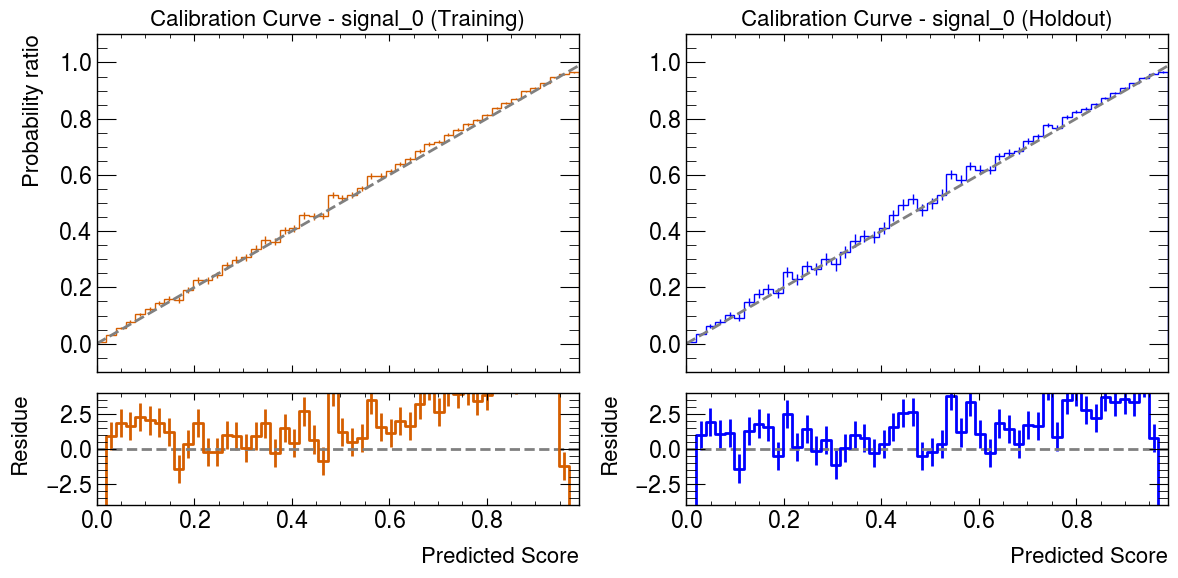

<Figure size 800x600 with 0 Axes>

In [15]:
trainer.make_calib_plots(observable='score', nbins=50, ensemble_index=0)